# 소문자 확장 실험 — 출력은 대문자 26클래스 유지

- 사용자가 `a`를 써도 UI에는 `A`가 뜨도록 한다.
- 채점은 **대소문자 무시 정확도**(`a`를 `A`로 답해도 정답으로 치는 정확도)로 한다.

| 실험 | 내용 | RTL 영향 |
|---|---|---|
| **(A) 채택** | `a`와 `A`를 같은 라벨로 26클래스 학습 | 없음 (FC3 `84→26` 그대로, 가중치만 바뀜) |
| (B) | 52클래스 학습 후 대소문자 합치기 (`max` / 확률합) | FC3 `84→52` + 비교기 또는 softmax |
| (C) | 대문자 모델 + 소문자 모델, 정답 case로 라우팅(oracle 상한) | 모델 2개 |
| (D) | 대소문자 분류기로 실제 라우팅, soft gating | 모델 3개 또는 2개 |

(A)~(D)는 소문자를 지원하는 방식이고, 그 뒤의 두 평가 섹션은 네 방식을 같은 기준으로 비교한다.

- 모델 구조·양자화·학습 규칙은 `cnn_golden`(`model.py`, `train.py`)을 그대로 쓴다. 출력 폭만 바꾼다.
- 데이터는 EMNIST `byclass`의 A-Z(10-35)와 a-z(36-61). test는 EMNIST 공식 test split이며 train과 분리된 NIST 원본 분할을 따른다.
- 학습 결과는 `../results/lowercase/`에 저장되고, 다시 실행하면 학습을 건너뛴다.
- EMNIST 정확도는 카메라 실측(글자당 약 0.95)보다 높다. 방식끼리의 **상대 비교**에 쓴다.

In [13]:
import sys
from pathlib import Path

import numpy as np
from torchvision.datasets import EMNIST

sys.path.insert(0, '..')  # tx/cnn/model -> cnn_golden package
from cnn_golden.train import SEED, VAL_FRACTION, split_train_val

DATA_ROOT = Path('~/repo/activity/LightLetter/tb/results/emnist').expanduser()
LETTERS = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'


def load_letters(partition):
    # Labels 0-25 = A-Z, 26-51 = a-z.
    dataset = EMNIST(root=str(DATA_ROOT), split='byclass', train=(partition == 'train'), download=False)
    images = np.transpose(dataset.data.numpy(), (0, 2, 1))  # same orientation fix as data.py
    labels = dataset.targets.numpy()
    keep = labels >= 10
    return images[keep].copy(), (labels[keep] - 10).astype(np.int64)


x_all, y_all = load_letters('train')
x, y, vx, vy = split_train_val(x_all, y_all, SEED, VAL_FRACTION)
tx, ty = load_letters('test')
letter, lower = ty % 26, ty >= 26
print('train', len(y), 'val', len(vy), 'test', len(ty), '| test lowercase share', round(lower.mean(), 3))
counts = np.bincount(ty, minlength=52)
print('test per class (upper):', dict(zip(LETTERS, counts[:26].tolist())))
print('test per class (lower):', dict(zip(LETTERS.lower(), counts[26:].tolist())))

train 317608 val 35289 test 58405 | test lowercase share 0.463
test per class (upper): {'A': 1062, 'B': 648, 'C': 1739, 'D': 779, 'E': 851, 'F': 1440, 'G': 447, 'H': 521, 'I': 2048, 'J': 626, 'K': 382, 'L': 810, 'M': 1485, 'N': 1351, 'O': 4156, 'P': 1397, 'Q': 413, 'R': 809, 'S': 3508, 'T': 1576, 'U': 2002, 'V': 796, 'W': 806, 'X': 432, 'Y': 798, 'Z': 464}
test per class (lower): {'a': 1644, 'b': 853, 'c': 432, 'd': 1683, 'e': 4092, 'f': 400, 'g': 589, 'h': 1479, 'i': 427, 'j': 317, 'k': 466, 'l': 2535, 'm': 464, 'n': 1898, 'o': 466, 'p': 368, 'q': 505, 'r': 2320, 's': 437, 't': 2965, 'u': 482, 'v': 468, 'w': 467, 'x': 470, 'y': 381, 'z': 451}


In [14]:
import copy

import torch
from torch.nn import functional as F

from cnn_golden import model as model_module
from cnn_golden.model import Net
from cnn_golden.train import BATCH_SIZE, EPOCHS, LR, batch

DEVICE = 'mps'
OUT = Path('../results/lowercase')
OUT.mkdir(parents=True, exist_ok=True)


def make_net(width):
    # Net reads FC_WIDTHS at construction; only the last FC width changes.
    model_module.FC_WIDTHS = [120, 84, width]
    try:
        torch.manual_seed(SEED)
        return Net().to(DEVICE)
    finally:
        model_module.FC_WIDTHS = [120, 84, 26]


@torch.no_grad()
def logits(net, images):
    net.eval()
    return np.concatenate([net(batch(images, slice(i, i + BATCH_SIZE), DEVICE)).float().cpu().numpy()
                           for i in range(0, len(images), BATCH_SIZE)])


def merge_case_max(z):
    # Score of a letter = larger of its uppercase and lowercase logits.
    return z.reshape(len(z), 2, 26).max(1).argmax(1)


def merge_case_prob(z):
    # Score of a letter = sum of its uppercase and lowercase softmax probabilities.
    p = torch.from_numpy(z).softmax(1).numpy()
    return p.reshape(len(z), 2, 26).sum(1).argmax(1)


def train(name, width, x, y, vx, vy, val_pred=lambda z: z.argmax(1), val_true=None):
    # Same loop as train.py (Adam, SEED, EPOCHS, BATCH_SIZE, best-val epoch); test is never used here.
    path = OUT / f'{name}.pt'
    net = make_net(width)
    if path.exists():
        saved = torch.load(path, map_location=DEVICE, weights_only=False)
        net.load_state_dict(saved['best_model'])
        print(name, 'loaded | best epoch', saved['best_epoch'], '| val', round(saved['best_val'], 4))
        return net
    val_true = vy if val_true is None else val_true
    optimizer = torch.optim.Adam(net.parameters(), lr=LR)
    best = (-1., None, None)
    history = []
    for epoch in range(EPOCHS):
        net.train()
        order = np.random.default_rng(SEED + epoch).permutation(len(y))
        for offset in range(0, len(y), BATCH_SIZE):
            ids = order[offset:offset + BATCH_SIZE]
            optimizer.zero_grad(set_to_none=True)
            F.cross_entropy(net(batch(x, ids, DEVICE)), torch.from_numpy(y[ids]).to(DEVICE)).backward()
            optimizer.step()
        val = float(np.mean(val_pred(logits(net, vx)) == val_true))
        history.append(val)
        if val > best[0]:
            best = (val, epoch + 1, copy.deepcopy(net.state_dict()))
        print(name, 'epoch', epoch + 1, 'val', round(val, 4), flush=True)
    torch.save(dict(best_model=best[2], best_epoch=best[1], best_val=best[0], history=history), path)
    net.load_state_dict(best[2])
    return net


def report(name, correct):
    print(f'{name:28s} all {correct.mean():.4f} | upper {correct[~lower].mean():.4f} | lower {correct[lower].mean():.4f}')


def per_letter(correct, mask):
    return {LETTERS[i]: round(float(correct[mask & (letter == i)].mean()), 3) for i in range(26)}


def top_confusions(pred, k=15):
    # Cross-letter errors only (case-insensitive), with the true case of the input.
    pairs = {}
    for t, p, lo in zip(letter, pred, lower):
        if t != p:
            key = (LETTERS[t].lower() if lo else LETTERS[t]) + '→' + LETTERS[p]
            pairs[key] = pairs.get(key, 0) + 1
    return sorted(pairs.items(), key=lambda kv: -kv[1])[:k]


results = {}  # name -> per-image case-insensitive correctness on the test set

## (A) 대소문자 합친 26클래스 라벨

`a`와 `A`를 둘 다 라벨 0으로 학습한다. FC3는 `84→26` 그대로라 RTL은 가중치만 바뀐다.

In [15]:
net_a = train('A-merged26', 26, x, y % 26, vx, vy % 26)
z_a = logits(net_a, tx)
pred = z_a.argmax(1)
results['(A) merged 26'] = pred == letter
report('(A) merged 26', results['(A) merged 26'])
print('upper per letter:', per_letter(results['(A) merged 26'], ~lower))
print('lower per letter:', per_letter(results['(A) merged 26'], lower))
print('top confusions:', top_confusions(pred))

A-merged26 loaded | best epoch 19 | val 0.9435
(A) merged 26                all 0.9413 | upper 0.9432 | lower 0.9391
upper per letter: {'A': 0.977, 'B': 0.958, 'C': 0.969, 'D': 0.883, 'E': 0.98, 'F': 0.965, 'G': 0.944, 'H': 0.927, 'I': 0.571, 'J': 0.947, 'K': 0.95, 'L': 0.953, 'M': 0.984, 'N': 0.98, 'O': 0.99, 'P': 0.983, 'Q': 0.879, 'R': 0.942, 'S': 0.99, 'T': 0.992, 'U': 0.973, 'V': 0.903, 'W': 0.973, 'X': 0.975, 'Y': 0.94, 'Z': 0.97}
lower per letter: {'A': 0.953, 'B': 0.973, 'C': 0.975, 'D': 0.977, 'E': 0.982, 'F': 0.927, 'G': 0.728, 'H': 0.944, 'I': 0.761, 'J': 0.839, 'K': 0.927, 'L': 0.846, 'M': 0.983, 'N': 0.97, 'O': 0.964, 'P': 0.951, 'Q': 0.683, 'R': 0.978, 'S': 0.963, 'T': 0.97, 'U': 0.956, 'V': 0.9, 'W': 0.976, 'X': 0.947, 'Y': 0.921, 'Z': 0.949}
top confusions: [('I→L', 857), ('l→I', 369), ('q→G', 108), ('g→Q', 89), ('i→L', 85), ('D→O', 75), ('V→U', 54), ('e→C', 38), ('t→F', 34), ('v→U', 30), ('C→E', 29), ('h→L', 28), ('j→I', 28), ('L→C', 24), ('Q→A', 23)]


## (B) 52클래스 학습 후 대소문자 합치기

`A`와 `a`를 다른 글자로 학습한 뒤(출력 52개), 마지막에 같은 글자의 대문자·소문자 점수를 하나로 합쳐 26개로 줄인다.
val 선택 기준은 `max`로 합친 뒤의 대소문자 무시 정확도다. 합치는 방법 두 가지를 비교한다.
- `max`: `max(logit[A], logit[a])` — RTL에서는 비교기 26개
- 확률합: `softmax[A] + softmax[a]` — RTL에서는 exp가 필요해 비싸다

In [16]:
net_b = train('B-52merge', 52, x, y, vx, vy, val_pred=merge_case_max, val_true=vy % 26)
z_b = logits(net_b, tx)
results['(B) 52 → merge max'] = merge_case_max(z_b) == letter
results['(B) 52 → merge prob'] = merge_case_prob(z_b) == letter
for name in ['(B) 52 → merge max', '(B) 52 → merge prob']:
    report(name, results[name])
print('case accuracy of the 52-way argmax before merging:', round(float(np.mean((z_b.argmax(1) >= 26) == lower)), 4))
print('top confusions (merge max):', top_confusions(merge_case_max(z_b)))

B-52merge loaded | best epoch 31 | val 0.9447
(B) 52 → merge max           all 0.9423 | upper 0.9503 | lower 0.9331
(B) 52 → merge prob          all 0.9422 | upper 0.9544 | lower 0.9282
case accuracy of the 52-way argmax before merging: 0.8753
top confusions (merge max): [('I→L', 687), ('l→I', 535), ('g→Q', 116), ('q→G', 89), ('i→L', 68), ('V→U', 56), ('e→C', 44), ('O→D', 43), ('D→O', 42), ('n→H', 32), ('j→I', 30), ('C→E', 29), ('U→V', 28), ('t→F', 27), ('v→U', 24)]


## (C) 대문자 모델 + 소문자 모델 — oracle 라우팅 상한

대문자 모델은 기존 대문자 전용 모델(`260927-uppercase-26cls`, test 0.9760), 소문자 모델은 소문자만으로 새로 학습한다.
정답 case로 보내는 oracle이 (A)와 비슷하면 분류기는 만들 필요가 없다.

`m`은 **잘못된 모델로 보냈을 때**의 대소문자 무시 정확도다. 대소문자 모양이 같은 글자는 `m ≈ l`이라 라우팅 실수의 손해가 작다.

In [17]:
BASELINE = Path('~/repo/activity/LightLetter/tb/results/260927-uppercase-26cls/ByClass-Uppercase/last.pt').expanduser()
SAME_SHAPE = set('COSVWXZ')  # hypothesis from the handoff: case differs only by size

upper_net = make_net(26)
upper_net.load_state_dict(torch.load(BASELINE, map_location=DEVICE, weights_only=False)['best_model'])
z_upper = logits(upper_net, tx)
low_train, low_val = y >= 26, vy >= 26
net_l = train('C-lower26', 26, x[low_train], y[low_train] - 26, vx[low_val], vy[low_val] - 26)
z_lower = logits(net_l, tx)
right_model = np.where(lower, z_lower.argmax(1), z_upper.argmax(1)) == letter   # l
wrong_model = np.where(lower, z_upper.argmax(1), z_lower.argmax(1)) == letter   # m
results['(C) oracle routing'] = right_model
report('(C) oracle routing (l)', right_model)
report('    wrong model (m)', wrong_model)
m_upper_in = per_letter(wrong_model, ~lower)
m_lower_in = per_letter(wrong_model, lower)
print('m, uppercase input → lowercase model:', m_upper_in)
print('m, lowercase input → uppercase model:', m_lower_in)
print('same-shape hypothesis', sorted(SAME_SHAPE), '| m ≥ 0.8 both ways:',
      sorted(k for k in LETTERS if m_upper_in[k] >= .8 and m_lower_in[k] >= .8))

C-lower26 loaded | best epoch 21 | val 0.9522
(C) oracle routing (l)       all 0.9629 | upper 0.9760 | lower 0.9477
    wrong model (m)          all 0.6229 | upper 0.8400 | lower 0.3714
m, uppercase input → lowercase model: {'A': 0.74, 'B': 0.681, 'C': 0.876, 'D': 0.585, 'E': 0.864, 'F': 0.92, 'G': 0.649, 'H': 0.714, 'I': 0.146, 'J': 0.861, 'K': 0.976, 'L': 0.902, 'M': 0.926, 'N': 0.868, 'O': 0.973, 'P': 0.934, 'Q': 0.453, 'R': 0.758, 'S': 0.975, 'T': 0.959, 'U': 0.88, 'V': 0.918, 'W': 0.962, 'X': 0.965, 'Y': 0.858, 'Z': 0.991}
m, lowercase input → uppercase model: {'A': 0.037, 'B': 0.111, 'C': 0.991, 'D': 0.01, 'E': 0.245, 'F': 0.932, 'G': 0.048, 'H': 0.248, 'I': 0.911, 'J': 0.596, 'K': 0.871, 'L': 0.021, 'M': 0.978, 'N': 0.271, 'O': 0.961, 'P': 0.946, 'Q': 0.226, 'R': 0.013, 'S': 0.954, 'T': 0.605, 'U': 0.971, 'V': 0.902, 'W': 0.957, 'X': 0.913, 'Y': 0.882, 'Z': 0.938}
same-shape hypothesis ['C', 'O', 'S', 'V', 'W', 'X', 'Z'] | m ≥ 0.8 both ways: ['C', 'F', 'K', 'M', 'O', 'P', 'S', '

## (D) 실제 라우팅 — 대소문자 분류기, soft gating

- 분류기: 같은 LeNet 구조, 출력 2개(대/소). 글자별 정확도 `c`를 본다.
- hard 라우팅: 분류기 결과대로 한 모델만 쓴다.
- soft mixture: `P(소)·softmax(소문자 모델) + P(대)·softmax(대문자 모델)`
- 분류기 없는 confidence gating: 두 모델 중 softmax 최댓값이 큰 쪽.

In [18]:
net_c = train('D-case2', 2, x, (y >= 26).astype(np.int64), vx, (vy >= 26).astype(np.int64))
z_case = logits(net_c, tx)
case_pred = z_case.argmax(1) == 1
case_ok = case_pred == lower
print(f'case classifier c: all {case_ok.mean():.4f} | upper {case_ok[~lower].mean():.4f} | lower {case_ok[lower].mean():.4f}')
print('c per letter (both cases):', {k: round(float(case_ok[letter == i].mean()), 3) for i, k in enumerate(LETTERS)})

p_up = torch.from_numpy(z_upper).softmax(1).numpy()
p_lo = torch.from_numpy(z_lower).softmax(1).numpy()
p_case = torch.from_numpy(z_case).softmax(1).numpy()
results['(D) hard routing'] = np.where(case_pred, p_lo.argmax(1), p_up.argmax(1)) == letter
results['(D) soft mixture'] = (p_case[:, :1] * p_up + p_case[:, 1:] * p_lo).argmax(1) == letter
results['(D) confidence gating'] = np.where(p_lo.max(1) > p_up.max(1), p_lo.argmax(1), p_up.argmax(1)) == letter
for name in ['(D) hard routing', '(D) soft mixture', '(D) confidence gating']:
    report(name, results[name])
wrong = ~case_ok
print('routing mistakes:', int(wrong.sum()), '| still correct:', round(float(results['(D) hard routing'][wrong].mean()), 3))

D-case2 loaded | best epoch 11 | val 0.8744
case classifier c: all 0.8733 | upper 0.9184 | lower 0.8212
c per letter (both cases): {'A': 0.953, 'B': 0.971, 'C': 0.766, 'D': 0.979, 'E': 0.974, 'F': 0.776, 'G': 0.954, 'H': 0.973, 'I': 0.579, 'J': 0.855, 'K': 0.712, 'L': 0.887, 'M': 0.762, 'N': 0.966, 'O': 0.898, 'P': 0.804, 'Q': 0.95, 'R': 0.976, 'S': 0.888, 'T': 0.954, 'U': 0.795, 'V': 0.648, 'W': 0.786, 'X': 0.731, 'Y': 0.714, 'Z': 0.726}
(D) hard routing             all 0.9380 | upper 0.9417 | lower 0.9337
(D) soft mixture             all 0.9401 | upper 0.9483 | lower 0.9306
(D) confidence gating        all 0.8991 | upper 0.9708 | lower 0.8161
routing mistakes: 7398 | still correct: 0.721


## 평가 1 — 5글자 단어 성공률

test 이미지 5장을 무작위로 뽑아 한 단어로 보고, 5글자가 모두 맞으면 성공으로 센다. 이 뽑기를 1만 번 반복해 성공 비율을 구한다(Monte Carlo 방식: 계산식 대신 무작위 반복으로 확률을 재는 방법). 글자 구성 3가지:
대문자만 / 소문자만 / 대소문자 반반(글자마다 50%).
같은 이미지 집합을 모든 방식에 공통으로 써서 방식끼리 바로 비교한다.

In [19]:
rng = np.random.default_rng(SEED)
N, L = 10_000, 5
upper_ids, lower_ids = np.flatnonzero(~lower), np.flatnonzero(lower)
draws = {
    'upper only': rng.choice(upper_ids, (N, L)),
    'lower only': rng.choice(lower_ids, (N, L)),
    'mixed 50/50': np.where(rng.random((N, L)) < .5, rng.choice(upper_ids, (N, L)), rng.choice(lower_ids, (N, L))),
}
rtl = {
    '(A) merged 26': 'weights only',
    '(B) 52 → merge max': 'FC3 84→52 + 26 comparators',
    '(B) 52 → merge prob': 'FC3 84→52 + softmax',
    '(C) oracle routing': 'upper bound, not buildable',
    '(D) hard routing': '3 networks',
    '(D) soft mixture': '3 networks + softmax',
    '(D) confidence gating': '2 networks + softmax',
}
print(f'{"method":24s} {"char(mixed)":>11s} ' + ' '.join(f'{k:>12s}' for k in draws) + '  RTL')
summary = {}
for name, correct in results.items():
    char = correct[draws['mixed 50/50']].mean()
    words = {k: correct[ids].all(1).mean() for k, ids in draws.items()}
    summary[name] = dict(char_mixed=float(char), **{k: float(v) for k, v in words.items()})
    print(f'{name:24s} {char:11.4f} ' + ' '.join(f'{v:12.4f}' for v in words.values()) + '  ' + rtl[name])

method                   char(mixed)   upper only   lower only  mixed 50/50  RTL
(A) merged 26                 0.9413       0.7448       0.7270       0.7371  weights only
(B) 52 → merge max            0.9425       0.7681       0.6940       0.7425  FC3 84→52 + 26 comparators
(B) 52 → merge prob           0.9422       0.7863       0.6809       0.7409  FC3 84→52 + softmax
(C) oracle routing            0.9619       0.8801       0.7595       0.8230  upper bound, not buildable
(D) hard routing              0.9384       0.7372       0.7018       0.7285  3 networks
(D) soft mixture              0.9402       0.7648       0.6857       0.7351  3 networks + softmax
(D) confidence gating         0.8949       0.8561       0.3519       0.5731  2 networks + softmax


## 평가 2 — 글자 1개 vs 5글자 단어, 표와 그래프

- 글자 1개: 그 경우의 이미지 하나를 맞힐 확률. `mixed`는 대문자·소문자 정확도의 평균(반반 섞인 입력).
- 5글자 단어: 평가 1의 값.
- 아래 히트맵은 글자별 정확도로, 어느 글자에서 손해가 나는지 보여 준다.

method                   |          1 letter          |       5-letter word       
                         |    upper    lower    mixed |    upper    lower    mixed
(A) merged 26            |   0.9432   0.9391   0.9411 |   0.7448   0.7270   0.7371
(B) 52 → merge max       |   0.9503   0.9331   0.9417 |   0.7681   0.6940   0.7425
(B) 52 → merge prob      |   0.9544   0.9282   0.9413 |   0.7863   0.6809   0.7409
(C) oracle routing       |   0.9760   0.9477   0.9619 |   0.8801   0.7595   0.8230
(D) hard routing         |   0.9417   0.9337   0.9377 |   0.7372   0.7018   0.7285
(D) soft mixture         |   0.9483   0.9306   0.9395 |   0.7648   0.6857   0.7351
(D) confidence gating    |   0.9708   0.8161   0.8935 |   0.8561   0.3519   0.5731


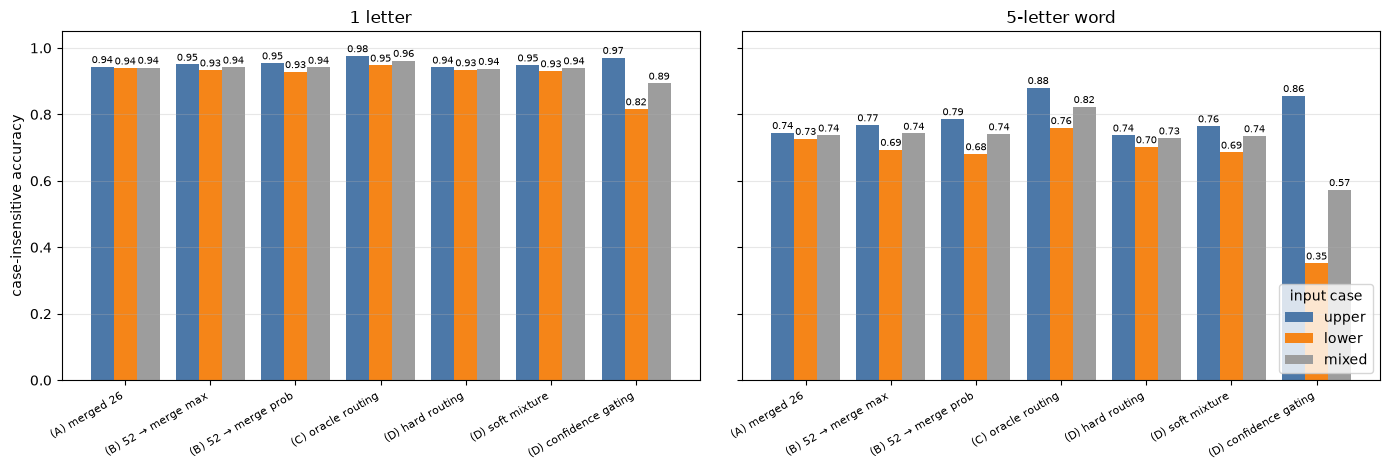

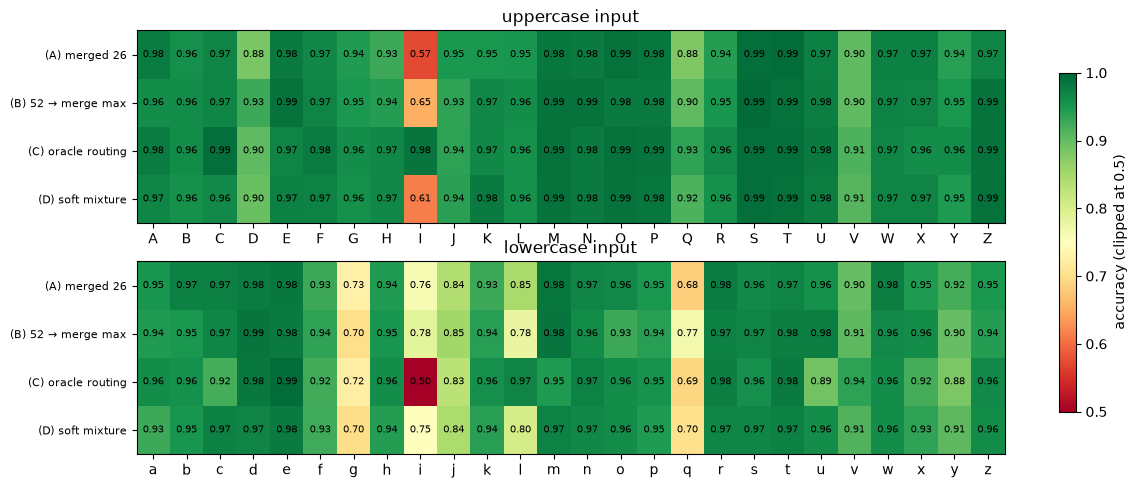

In [20]:
import matplotlib.pyplot as plt

one = {}
for name, correct in results.items():
    u, l = correct[~lower].mean(), correct[lower].mean()
    one[name] = dict(upper=float(u), lower=float(l), mixed=float((u + l) / 2))
five = {name: {'upper': s['upper only'], 'lower': s['lower only'], 'mixed': s['mixed 50/50']}
        for name, s in summary.items()}

print(f'{"method":24s} | {"1 letter":^26s} | {"5-letter word":^26s}')
print(f'{"":24s} | {"upper":>8s} {"lower":>8s} {"mixed":>8s} | {"upper":>8s} {"lower":>8s} {"mixed":>8s}')
for name in results:
    print(f'{name:24s} | ' + ' '.join(f'{v:8.4f}' for v in one[name].values())
          + ' | ' + ' '.join(f'{v:8.4f}' for v in five[name].values()))

shown = list(results)
scenarios = ['upper', 'lower', 'mixed']
colors = ['#4C78A8', '#F58518', '#9D9D9D']
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ax, (title, table) in zip(axes, [('1 letter', one), ('5-letter word', five)]):
    pos = np.arange(len(shown))
    for k, (scenario, color) in enumerate(zip(scenarios, colors)):
        values = [table[n][scenario] for n in shown]
        bars = ax.bar(pos + (k - 1) * .27, values, .27, label=scenario, color=color)
        ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=1)
    ax.set_xticks(pos, shown, rotation=30, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=.3)
axes[0].set_ylabel('case-insensitive accuracy')
axes[1].legend(title='input case', loc='lower right')
plt.tight_layout()
plt.show()

picked = [n for n in shown if n.startswith(('(A)', '(B) 52 → merge max', '(C)', '(D) soft'))]
fig, axes = plt.subplots(2, 1, figsize=(14, 5.5))
for ax, (title, mask, names) in zip(axes, [('uppercase input', ~lower, LETTERS), ('lowercase input', lower, LETTERS.lower())]):
    grid = np.array([[results[n][mask & (letter == i)].mean() for i in range(26)] for n in picked])
    image = ax.imshow(grid, cmap='RdYlGn', vmin=.5, vmax=1, aspect='auto')
    for (r, c), v in np.ndenumerate(grid):
        ax.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=7)
    ax.set_xticks(range(26), list(names))
    ax.set_yticks(range(len(picked)), picked, fontsize=8)
    ax.set_title(title)
fig.colorbar(image, ax=axes, shrink=.8, label='accuracy (clipped at 0.5)')
plt.show()

## 정리 — (A) 채택 (2026-10-09)

**(A) 대소문자 같은 라벨 26클래스**

| 방식 | 전체 정확도 | 판단 |
|---|---|---|
| (C) oracle | 0.9629 | 정답 case를 알아야 해서 만들 수 없다. crop·resize 뒤에는 `c`/`C` 같은 글자의 case 정보가 남지 않는다 |
| (B) 52 → `max` / 확률합 | 0.9423 | (A)보다 0.1%p 높을 뿐이고, FC3 `84→52`와 비교기(또는 softmax)가 늘어난다 |
| **(A) merged 26** | **0.9413** | FC3 `84→26`과 RTL 구조가 그대로다. 가중치만 바뀐다 |
| (D) hard / soft | 0.938 / 0.940 | case 분류기가 0.873에 그쳐 (A)를 넘지 못하고, 네트워크 3개가 필요하다 |
| (D) confidence | 0.8991 | 대문자 모델이 소문자 입력에 확신을 갖고 틀린다 |

남은 문제는 대문자 `I`다. 손글씨 `I`와 소문자 `l`이 같은 세로 막대라 `I→L`로 오인된다 (대문자 `I` 0.571).